# Inventory & Sales Analytics – Data Cleaning & EDA
Raw CSVs (`data/raw`) → cleaned CSVs (`data/clean`) that get loaded into PostgreSQL and Power BI.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name in ('python', 'notebooks') else Path.cwd()
RAW, CLEAN = ROOT/'data'/'raw', ROOT/'data'/'clean'
sales = pd.read_csv(RAW/'raw_sales.csv'); prod = pd.read_csv(RAW/'raw_products.csv'); rest = pd.read_csv(RAW/'raw_restocks.csv')
for n, d in [('sales', sales), ('products', prod), ('restocks', rest)]:
    print(n, d.shape); print(d.isna().sum()[lambda s: s>0].to_dict(), '| dup rows:', d.duplicated().sum())

sales (63053, 6)
{'quantity': 378, 'unit_price': 631, 'store': 252} | dup rows: 415
products (60, 8)
{} | dup rows: 0
restocks (556, 3)
{} | dup rows: 0


## 1. Profile the problems
- duplicate order lines
- missing `quantity`, `unit_price`, `store`
- 3 different date formats and prices stored as text (`$12.50`)
- inconsistent category casing / stray spaces

In [2]:
print(sales.order_date.sample(6, random_state=1).tolist()); print(prod.category.unique())

['2024-04-13', '2025-03-03', '2024-02-22', '2024-12-28', '14/04/2025', '2025-04-22']
<ArrowStringArray>
[      'BEVERAGES',       'Beverages',     ' beverages ',        ' snacks ',
          'Snacks',          'SNACKS',       'Household',       'HOUSEHOLD',
   'Personal Care', ' personal care ',         'Staples',         'STAPLES']
Length: 12, dtype: str


## 2. Clean products

In [3]:
prod['category'] = prod.category.str.strip().str.title()
prod['unit_price'] = prod.unit_price.str.replace('$', '', regex=False).astype(float)
prod['product_name'] = prod.product_name.str.strip()
assert prod.product_id.is_unique
print(prod.category.value_counts())

category
Beverages        12
Snacks           12
Household        12
Personal Care    12
Staples          12
Name: count, dtype: int64


## 3. Clean sales
Rules: parse dates per format · strip `$` · fill missing price from the product master (same product = same price) · missing store → `Unknown` · **drop** rows with missing quantity (can't be inferred, <1%) · remove duplicate `order_id`s keeping the most complete row.

In [4]:
def parse_date(s):
    out = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    for f in ('%d/%m/%Y', '%d-%b-%Y'):
        out = out.fillna(pd.to_datetime(s, format=f, errors='coerce'))
    return out

n0 = len(sales)
sales['order_date'] = parse_date(sales.order_date)
assert sales.order_date.notna().all()
sales['unit_price'] = sales.unit_price.str.replace('$', '', regex=False).astype(float)
# duplicates: keep the row with fewest missing values
sales['_nulls'] = sales.isna().sum(axis=1)
sales = sales.sort_values(['order_id', '_nulls']).drop_duplicates('order_id', keep='first').drop(columns='_nulls')
n_dups = n0 - len(sales)
# missing price -> product master
price_map = prod.set_index('product_id').unit_price
missing_price = sales.unit_price.isna().sum()
sales['unit_price'] = sales.unit_price.fillna(sales.product_id.map(price_map))
sales['store'] = sales.store.fillna('Unknown')
missing_qty = sales.quantity.isna().sum()
sales = sales.dropna(subset=['quantity']).astype({'quantity': int})
sales['revenue'] = (sales.quantity * sales.unit_price).round(2)
sales = sales.sort_values('order_date').reset_index(drop=True)
print(f'duplicates removed: {n_dups} | prices filled: {missing_price} | rows dropped (no qty): {missing_qty} | final rows: {len(sales)}')
assert sales.notna().all().all() and sales.order_id.is_unique and (sales.quantity > 0).all()

duplicates removed: 748 | prices filled: 621 | rows dropped (no qty): 367 | final rows: 61938


## 4. Clean restocks & validate

In [5]:
rest['restock_date'] = pd.to_datetime(rest.restock_date); rest['quantity'] = rest.quantity.astype(int)
rest = rest.drop_duplicates()
assert set(sales.product_id) <= set(prod.product_id) and set(rest.product_id) <= set(prod.product_id)
sales.to_csv(CLEAN/'sales.csv', index=False, date_format='%Y-%m-%d')
prod.to_csv(CLEAN/'products.csv', index=False)
rest.to_csv(CLEAN/'restocks.csv', index=False, date_format='%Y-%m-%d')
print('saved', len(sales), len(prod), len(rest))

saved 61938 60 556


## 5. Exploratory analysis & KPIs (pandas)
The same KPIs are computed again in SQL (`sql/03_analysis_queries.sql`); the two must agree.

Total sales: 1794953.76 | units: 115396


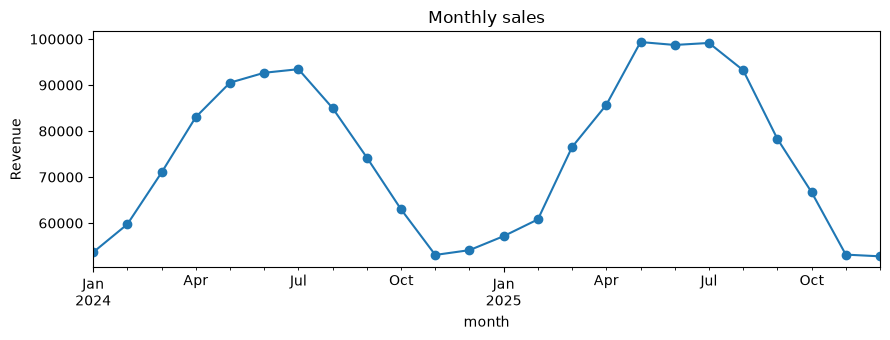

In [6]:
sales['month'] = sales.order_date.dt.to_period('M')
print('Total sales:', round(sales.revenue.sum(), 2), '| units:', sales.quantity.sum())
monthly = sales.groupby('month').revenue.sum()
ax = monthly.plot(marker='o', figsize=(9, 3.5), title='Monthly sales'); ax.set_ylabel('Revenue'); plt.tight_layout(); plt.show()

In [7]:
opening = rest.sort_values('restock_date').groupby('product_id').quantity.first()
units = sales.groupby('product_id').quantity.sum()
k = prod.set_index('product_id').join(units.rename('units_sold'))
k['avg_stock'] = (opening + k.current_stock) / 2
k['stock_turnover'] = (k.units_sold / k.avg_stock).round(2)
k['needs_reorder'] = k.current_stock <= k.reorder_level
print(k.sort_values('units_sold', ascending=False).head(10)[['product_name', 'category', 'units_sold', 'stock_turnover']])
print(k.sort_values('stock_turnover').head(5)[['product_name', 'units_sold', 'stock_turnover']])
print('Items at/below reorder level:', k.needs_reorder.sum())

                 product_name       category  units_sold  stock_turnover
product_id                                                              
P1039       Body Lotion 400ml  Personal Care        6419           15.17
P1009          Iced Tea 500ml      Beverages        6198           11.46
P1013       Potato Chips 150g         Snacks        4138           12.91
P1033         Hand Wash 250ml      Household        4062           13.56
P1048                Lip Balm  Personal Care        4051            8.18
P1051        Sunflower Oil 1L        Staples        4030            3.38
P1012             Lemonade 1L      Beverages        3977            5.98
P1052               Sugar 1kg        Staples        3957           19.26
P1043               Razor 3pk  Personal Care        3953            7.77
P1004        Mineral Water 1L      Beverages        3731            5.79
                     product_name  units_sold  stock_turnover
product_id                                                   


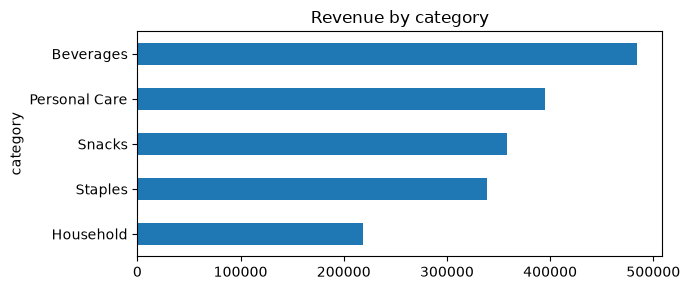

In [8]:
cat = sales.merge(prod[['product_id', 'category']], on='product_id').groupby('category').revenue.sum().sort_values()
cat.plot.barh(figsize=(7, 3), title='Revenue by category'); plt.tight_layout(); plt.show()

**Findings:** sales rise through the two years with a summer peak in Beverages; a small group of fast movers drives most units sold, while several products turn over far slower than the rest; the products flagged `needs_reorder` are the ones the Power BI reorder-alert table highlights.